In [1]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import WhitespaceTokenizer
from nltk import pos_tag
from nltk.corpus import wordnet
import nltk

nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

### Sources:

*   [GloVe Embedding article](https://medium.com/analytics-vidhya/basics-of-using-pre-trained-glove-vectors-in-python-d38905f356db)
*    [Emojis - source1](https://towardsdatascience.com/emojis-aid-social-media-sentiment-analysis-stop-cleaning-them-out-bb32a1e5fc8e)
*   [Emojis - source2](https://medium.com/@HeCanThink/emoji-lets-deal-with-in-python-dcc88b1f8ab1)
*   [Emojis - source3](https://kt.ijs.si/data/Emoji_sentiment_ranking/)
*   [Spell checker - source 1](https://www.johnsnowlabs.com/easily-correcting-typos-and-spelling-errors-on-texts-with-spark-nlp-and-python/)
*   [Spell checker - source 2](https://stackoverflow.com/questions/69851442/q-python-spell-checker-using-nltk)
*   [Lemmatization with a pretrained model - Spark NLP](https://sparknlp.org/2021/11/22/lemma_antbnc_en.html)

In [2]:
import pandas as pd
import gensim
import emoji
import nltk
import torch
import sys
import shutil
import urllib
import tarfile
from pathlib import Path
import numpy as np
from typing import Iterable
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import gensim.downloader as gloader
from gensim.models import KeyedVectors
from autocorrect import Speller
import os
import simplejson as sj

import pandas as pd
from typing import List, Callable, Dict
from collections import OrderedDict
import umap

import re

from sklearn.metrics.pairwise import cosine_similarity


## hashtags segmenter: https://github.com/grantjenks/python-wordsegment
import wordsegment as ws 
ws.load()

## mention and lemmatization
import spacy
nlp = spacy.load("en_core_web_sm")

LEMMATIZED_TRAIN_DATA_FILE = "training_data_lemm.csv"
LEMMATIZED_VALIDATION_DATA_FILE = "validation_data_lemm.csv"
LEMMATIZED_TEST_DATA_FILE = "test_data_lemm.csv"

c:\Users\andre\Desktop\AlmaMater\NLP\Assignment\Assignment 1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\andre\Desktop\AlmaMater\NLP\Assignment\Assignment 1\.venv\Lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [3]:
# choose right device
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print('Torch Device: %s' % device)

Torch Device: cpu


# Data Visualization
Download data, Load Json in Pandas dataframes, Generate Hard Labels, Filter English, Filter columns, Encode Hard Label in 0-1

# Data Cleaning

In [4]:
## REGEXs
GOOD_SYMBOLS_RE = re.compile('[^0-9a-z +_<>]')
HASHTAG_REGEX = re.compile('#\w+')
MENTION_REGEX = re.compile("@\w+")
URL_REGEX = re.compile('https?://(?:www\.)?[\w-]+\.[\w/._-]+')
## SPECIAL TOKENs
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_GREATER_THAN = " <GREATER_THAN> "
TOKEN_LEFT_SINGLE_QUOTE = " <LEFT_SINGLE_QUOTE> "
TOKEN_RIGHT_SINGLE_QUOTE = " <RIGHT_SINGLE_QUOTE> "
TOKEN_LEFT_DOUBLE_QUOTE = " <LEFT_DOUBLE_QUOTE> "
TOKEN_RIGHT_DOUBLE_QUOTE = " <RIGHT_DOUBLE_QUOTE> "
TOKEN_ELLIPSIS = " <ELLIPSIS> "
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_URL = " <URL> "
TOKEN_HASHTAG_START = " <HASHTAG_START> "
TOKEN_HASHTAG_END = " <HASHTAG_END> "

try:
    STOPWORDS = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    STOPWORDS = set(stopwords.words('english'))

In [5]:
def lower(text):
    return text.lower()

def strip_text(text):
    return text.strip()

def contains_emoji(text):
    return any(emoji.is_emoji(char) for char in text)

def contains_mention(text):
    return re.findall(MENTION_REGEX, text)

def replace_urls_with_token(text):
    return re.sub(URL_REGEX, TOKEN_URL, text)

def remove_angle_brackets(text):
    text.replace("&amp", " and ")
    text.replace("<", TOKEN_LESSER_THAN)
    text.replace(">", TOKEN_GREATER_THAN)
    return text

def emoji2description(text):
    return emoji.replace_emoji(text, replace=lambda chars, data_dict: ' '.join(data_dict['en'].split('_')).strip(':')+' ')

def encode_data_with_function(data, encoding, column = 'tweet'):
    data[column] = data[column].apply(encoding)
    return data

def replace_quote_symbols(text):
    text = text.replace("‘", TOKEN_LEFT_SINGLE_QUOTE)
    text = text.replace("’", TOKEN_RIGHT_SINGLE_QUOTE)
    text = text.replace("“", TOKEN_LEFT_DOUBLE_QUOTE)
    text = text.replace("”", TOKEN_RIGHT_DOUBLE_QUOTE)
    text = text.replace("\"", TOKEN_LEFT_DOUBLE_QUOTE)
    text = text.replace("\"", TOKEN_RIGHT_DOUBLE_QUOTE)
    text = text.replace("...", TOKEN_ELLIPSIS)
    return text

def replace_mention(text):
    mention = re.findall(MENTION_REGEX, text)
    if mention:
        new_sen = text
        for m in mention:
            doc = nlp(m)
            sub = [c.label_ for c in doc.ents]
            if sub:
                new_sen = new_sen.replace(m, f" <{sub[0]}> ")
            else:
                new_sen = new_sen.replace(m, f" <{[c.pos_ for c in doc][0]}> ")
        return new_sen
    else:
        return text    
    
def replace_hashtag(text):
    """
    Replaces hashtags, by segmenting hashtags and adding special tokens in front and at the end of it.
    """
    def segment(x) :
        return TOKEN_HASHTAG_START+' '.join(ws.segment(x))+TOKEN_HASHTAG_END
    return re.sub(HASHTAG_REGEX, lambda x: segment(x.group(0)), text)


# def replace_special_characters(text: str) -> str:
#     """
#     Replaces special characters, such as paranthesis, with spacing character
#     """
#     return REPLACE_BY_SPACE_RE.sub(' ', text)

def replace_br(text: str) -> str:
    """
    Replaces br characters
    """
    return text.replace('br', '')

def filter_out_unwanted_symbols(text: str) -> str:
    """
    Removes any special character that is not in the good symbols list (check regular expression)
    """
    return GOOD_SYMBOLS_RE.sub(' ', text)

def remove_stopwords(text: str) -> str:
    return ' '.join([x for x in text.split() if x and x not in STOPWORDS])

def strip_text(text: str) -> str:
    """
    Removes any left or right spacing (including carriage return) from text.
    """
    return text.strip()

In [6]:
def majority_vote(lst):
    count = Counter(lst)
    return 1 if count.most_common(1)[0][0] == "YES" else 0

def yes_probability(lst):
    # Count the number of YES and NO votes
    yes_count = lst.count("YES")
    no_count = lst.count("NO")

    # Calculate the probability of YES
    total = yes_count + no_count
    if total == 0:
        return None  # To handle cases where there are no "YES" or "NO" votes in the list
    else:
        return yes_count / total

def generate_labels_task1(data):
    data = data.drop(['annotators','number_annotators','gender_annotators','age_annotators','labels_task2','labels_task3'],axis=1)
    data['hard_label_task1'] = data['labels_task1'].apply(majority_vote)
    data['soft_label_task1'] = data['labels_task1'].apply(yes_probability)
    return data

# def load_and_preprocess_dataset(file_path):
#     data = pd.read_json(file_path).T
#     data = generate_labels_task1(data)
#     data['original'] = data['tweet'] #to remove
#     columns_to_keep = ['id_EXIST','lang','tweet', 'hard_label_task1','soft_label_task1', 'original']
#     data = data[columns_to_keep]
#     data = filter_english_only(data)
#     data = encode_data_with_function(data,remove_angle_brackets)
#     data = encode_data_with_function(data,emoji2description)
#     data = encode_data_with_function(data,replace_mention)
#     data = encode_data_with_function(data,replace_hashtag)
#     data = encode_data_with_function(data,replace_urls_with_token)
#     data = encode_data_with_function(data,replace_quote_symbols)
#     # data = encode_data_with_function(data,replace_special_characters)
#     data = encode_data_with_function(data,filter_out_unwanted_symbols)
#     #data = encode_data_with_function(data,replace_br)
#     data = encode_data_with_function(data,remove_stopwords)
#     data = encode_data_with_function(data,lower)
#     data = encode_data_with_function(data,strip_text)
#     return data

def load_dataset(file_path):
  return pd.read_json(file_path).T

def load_and_preprocess_dataset_new(file_path, verbose = True, index_to_print=1):
    # Load and transpose the data
    data = pd.read_json(file_path).T
    if verbose:
      print(f"Initial Data (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Generate labels for task 1
    data = generate_labels_task1(data)
    if verbose:
      print(f"After generate_labels_task1 (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Add 'original' column (to remove)
    data['original'] = data['tweet']

    # Keep only necessary columns
    columns_to_keep = ['id_EXIST', 'lang', 'tweet', 'hard_label_task1', 'soft_label_task1', 'original']
    data = data[columns_to_keep]
    if verbose:
      print(f"After keeping specific columns (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Filter for English-only data
    data = filter_english_only(data)
    if verbose:
      print(f"After filter_english_only (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")

    # Apply each encoding function and print the result
    encoding_functions = [
        remove_angle_brackets,
        emoji2description,
        replace_mention,
        replace_hashtag,
        replace_urls_with_token,
        replace_quote_symbols,
        # replace_special_characters,
        lower,
        filter_out_unwanted_symbols,
        remove_stopwords,
        strip_text
    ]

    for func in encoding_functions:
        data = encode_data_with_function(data, func)
        if verbose:
          print(f"After {func.__name__} (index == {index_to_print}):\n", data.loc[index_to_print]['tweet'] if index_to_print in data.index else "Index not found")

    return data


def filter_english_only(df):
    new_df = df[df['lang'].astype('str').str.contains('en')]
    return new_df


In [7]:
#Debug purpose
load_and_preprocess_dataset_new("data/training.json", verbose=True, index_to_print=202722)

Initial Data (index == 202722):
 id_EXIST                                                        202722
lang                                                                en
tweet                Today’s women are not the same as women were i...
number_annotators                                                    6
annotators           [Annotator_720, Annotator_721, Annotator_722, ...
gender_annotators                                   [F, F, M, M, M, F]
age_annotators                  [18-22, 23-45, 18-22, 23-45, 46+, 46+]
labels_task1                              [YES, NO, NO, YES, YES, YES]
labels_task2               [JUDGEMENTAL, -, -, DIRECT, DIRECT, DIRECT]
labels_task3         [[IDEOLOGICAL-INEQUALITY], [-], [-], [STEREOTY...
split                                                         TRAIN_EN
Name: 202722, dtype: object
After generate_labels_task1 (index == 202722):
 id_EXIST                                                       202722
lang                                    

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
200001,200001,en,ffs laying blame bastard murdered novel idea k...,1,0.500000,FFS! How about laying the blame on the bastard...
200002,200002,en,writing uni essay local pub coffee random old ...,1,0.833333,Writing a uni essay in my local pub with a cof...
200003,200003,en,<noun> 2021 1921 dont appreciate two rides tea...,1,0.666667,@UniversalORL it is 2021 not 1921. I dont appr...
200004,200004,en,<org> unacceptable use title men interviewed f...,1,0.500000,@GMB this is unacceptable. Use her title as yo...
200005,200005,en,<left_single_quote> making harder target <righ...,1,0.500000,‘Making yourself a harder target’ basically bo...
...,...,...,...,...,...,...
203256,203256,en,idk <right_single_quote> bitches think half as...,1,1.000000,idk why y’all bitches think having half your a...
203257,203257,en,part experiment <org> learning though little b...,1,1.000000,This has been a part of an experiment with @Wo...
203258,203258,en,<left_double_quote> take already <left_double_...,1,0.666667,"""Take me already"" ""Not yet. You gotta be ready..."
203259,203259,en,<person> look like whore lh <url>,1,1.000000,@clintneedcoffee why do you look like a whore?...


In [8]:
processed_training_data = load_and_preprocess_dataset_new("data/training.json", verbose=False)
print('Finished training')
processed_validation_data = load_and_preprocess_dataset_new("data/validation.json", verbose=False)
print('Finished validation')
processed_test_data = load_and_preprocess_dataset_new("data/test.json", verbose=False)
print('Finished test')

Finished training
Finished validation
Finished test


In [9]:
print(processed_training_data.shape)
print(processed_validation_data.shape)
print(processed_test_data.shape)

print(processed_training_data.columns)


(3260, 6)
(177, 6)
(312, 6)
Index(['id_EXIST', 'lang', 'tweet', 'hard_label_task1', 'soft_label_task1',
       'original'],
      dtype='object')


In [10]:
display(processed_training_data.head())

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
200001,200001,en,ffs laying blame bastard murdered novel idea k...,1,0.500000,FFS! How about laying the blame on the bastard...
200002,200002,en,writing uni essay local pub coffee random old ...,1,0.833333,Writing a uni essay in my local pub with a cof...
200003,200003,en,<noun> 2021 1921 dont appreciate two rides tea...,1,0.666667,@UniversalORL it is 2021 not 1921. I dont appr...
200004,200004,en,<org> unacceptable use title men interviewed f...,1,0.500000,@GMB this is unacceptable. Use her title as yo...
200005,200005,en,<left_single_quote> making harder target <righ...,1,0.500000,‘Making yourself a harder target’ basically bo...


In [11]:
target = "hard_label_task1"

In [12]:
processed_training_data[target].value_counts()

hard_label_task1
0    1941
1    1319
Name: count, dtype: int64

Train '0:1' score ratio --> 1.47 : 1
Test  '0:1' score ratio --> 1.21 : 1


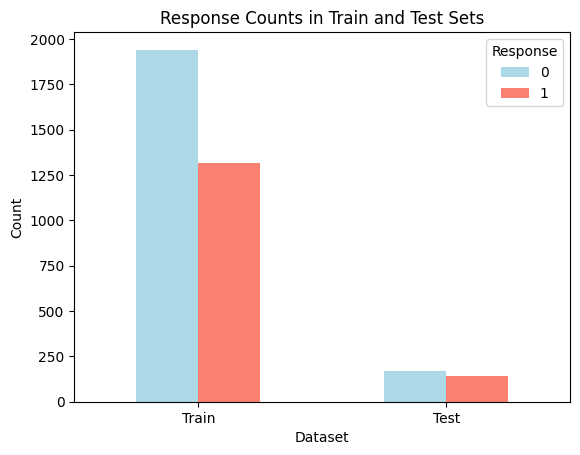

In [13]:
train_counts = processed_training_data[target].value_counts()
test_counts = processed_test_data[target].value_counts()

# Combine counts into a single DataFrame for plotting
counts_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
}).T  # Transpose to have "yes" and "no" as columns

print(f"Train '0:1' score ratio --> {counts_df[0]['Train']/counts_df[1]['Train']:.2f} : 1")
print(f"Test  '0:1' score ratio --> {counts_df[0]['Test']/counts_df[1]['Test']:.2f} : 1")

# Plotting
counts_df.plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Response Counts in Train and Test Sets')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Response')
plt.show()

## Lemmatization - Same as Tutorial 1

In [14]:
def get_wordnet_key(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:          
        return 'n'

def lem_text(text, lemmatizer = WordNetLemmatizer(), tokenizer = WhitespaceTokenizer(), spell_checker=True, spell=Speller(lang='en')):
    _text = []
    # segment all words that does not contain a '<' inside
    for t in text.split(" "):
        _text += [t if "<" in t else ' '.join(ws.segment(t))]
    text = ' '.join(_text)

    # check for mis-spelling of words
    tokens = tokenizer.tokenize(text)
    if spell_checker:
      tokens = [spell(w) for w in tokens]
    # lemmatize words by their semantics
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag)) for word, tag in tagged]
    return " ".join(words)

In [15]:
def load_lemmatized_data(preprocessed_data, lem_fn=lem_text , path=""):
    if not os.path.isfile(path):
        lem_data = encode_data_with_function(preprocessed_data,lem_fn)
        lem_data.to_csv(path)
        return lem_data
    else:
        return pd.read_csv(path)

In [16]:
# load lemmatized training data
print("Lemmatizing training data.")
lem_training_data = load_lemmatized_data(processed_training_data, path=LEMMATIZED_TRAIN_DATA_FILE)
# load lemmatized validation data
print("Lemmatizing validation data.")
lem_validation_data = load_lemmatized_data(processed_validation_data, path=LEMMATIZED_VALIDATION_DATA_FILE)
# load lemmatized test data
print("Lemmatizing test data.")
lem_test_data = load_lemmatized_data(processed_test_data, path=LEMMATIZED_TEST_DATA_FILE)

Lemmatizing training data.
Lemmatizing validation data.
Lemmatizing test data.


# Task 3 - Text encoding

In [17]:
EMB_DIM = 50

In [18]:
def load_embedding_model(model_type: str,
                         embedding_dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library.

    :param model_type: name of the word embedding model to load.
    :param embedding_dimension: size of the embedding space to consider

    :return
        - pre-trained word embedding model (gensim KeyedVectors object)
    """
    download_path = ""
    # https://github.com/piskvorky/gensim-data?tab=readme-ov-file#datasets
    if model_type.strip().lower() == 'word2vec':
        download_path = "word2vec-google-news-300"
    elif model_type.strip().lower() == 'glove':
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'glove-twitter':
        download_path = "glove-twitter-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'fasttext':
        download_path = "fasttext-wiki-news-subwords-300"
    else:
        raise AttributeError("Unsupported embedding model type! Available ones: word2vec, glove, fasttext")
        
    try:
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name! Check the embedding dimension:")
        print("Word2Vec: 300")
        print("Glove: 50, 100, 200, 300")
        print("Glove-twitter: 25, 50, 100, 200")
        print('FastText: 300')
        raise e

    return emb_model

In [19]:
embedding_model = load_embedding_model(model_type="glove-twitter",
                                       embedding_dimension=EMB_DIM)

[==================================================] 100.0% 199.5/199.5MB downloaded


In [20]:
df_embed = pd.DataFrame(data=embedding_model.vectors)
df_embed.describe()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
count,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,...,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06,1.193514e+06
mean,-2.189694e-01,1.726908e-01,-5.617134e-02,6.307274e-02,9.606626e-03,-2.346111e-01,-1.673192e-01,-2.561416e-01,1.299083e-01,-3.417983e-01,...,8.865857e-01,-1.498127e-02,1.021143e-01,-1.295955e-01,-3.283582e-01,1.301438e-01,-2.061018e-02,5.735761e-02,1.400820e-01,2.258864e-01
std,6.761081e-01,6.944407e-01,6.916828e-01,6.787786e-01,6.724812e-01,6.458723e-01,6.574651e-01,6.568925e-01,6.580209e-01,6.958572e-01,...,6.979791e-01,7.033525e-01,6.897094e-01,6.691399e-01,6.530790e-01,6.655709e-01,6.396263e-01,6.755373e-01,6.775005e-01,7.008290e-01
min,-6.841300e+00,-5.047700e+00,-5.438000e+00,-5.890500e+00,-5.565400e+00,-5.154800e+00,-4.560500e+00,-6.026900e+00,-6.973900e+00,-5.919400e+00,...,-5.068500e+00,-6.539600e+00,-4.826100e+00,-5.101300e+00,-6.305100e+00,-5.560800e+00,-6.061000e+00,-4.887500e+00,-5.418700e+00,-5.085200e+00
25%,-6.413400e-01,-2.436100e-01,-4.679675e-01,-3.681900e-01,-4.101000e-01,-6.339200e-01,-5.818400e-01,-6.666175e-01,-2.842500e-01,-7.918400e-01,...,4.949600e-01,-4.598200e-01,-3.346475e-01,-5.460300e-01,-7.529800e-01,-2.694100e-01,-4.273100e-01,-3.651200e-01,-2.839800e-01,-2.194600e-01
50%,-2.189900e-01,2.007850e-01,-4.527100e-02,5.317900e-02,4.772650e-03,-2.469000e-01,-1.770900e-01,-2.591700e-01,1.371100e-01,-3.565800e-01,...,9.351600e-01,-2.827900e-02,1.090500e-01,-1.173900e-01,-3.416500e-01,1.419800e-01,-2.246000e-02,6.179700e-02,1.519800e-01,2.088050e-01
75%,2.080900e-01,6.189800e-01,3.714400e-01,4.816900e-01,4.271400e-01,1.549200e-01,2.374700e-01,1.492100e-01,5.490300e-01,9.211150e-02,...,1.337700e+00,4.182375e-01,5.358700e-01,3.018000e-01,8.437975e-02,5.460100e-01,3.849000e-01,4.888800e-01,5.653500e-01,6.511900e-01
max,5.123200e+00,5.519100e+00,5.251400e+00,6.513400e+00,6.321600e+00,5.412600e+00,4.639100e+00,5.666800e+00,5.547700e+00,4.933300e+00,...,5.409900e+00,5.424700e+00,5.582800e+00,5.098700e+00,5.321000e+00,4.581900e+00,4.588900e+00,4.855900e+00,5.119900e+00,5.938800e+00


In [21]:
def build_vocabulary(df: pd.DataFrame, add_glove_tokens = False, model = None, additional_tokens = None) -> (Dict[int, str], Dict[str, int], List[str]):
    """
    Builds a vocabulary that is the union of tokens from the dataset and model embeddings.

    :param df: pandas DataFrame containing the dataset (column 'tweet' with sentences).
    :param model: Model object containing pre-trained embeddings.
    :return:
      - idx_to_word: Dictionary mapping vocabulary index to word.
      - word_to_idx: Dictionary mapping word to vocabulary index.
      - word_listing: List of unique terms in the vocabulary.
    """
    idx_to_word = OrderedDict()
    word_to_idx = OrderedDict()
    
    # Add tokens from training set
    curr_idx = 0
    for sentence in tqdm(df['tweet'].values, desc="Building vocabulary from dataset"):
        tokens = sentence.split()
        for token in tokens:
            if token not in word_to_idx:
                word_to_idx[token] = curr_idx
                idx_to_word[curr_idx] = token
                curr_idx += 1
    
    # Add tokens from GloVe (via Gensim)
    if add_glove_tokens:
      for token in tqdm(model.key_to_index, desc="Adding GloVe tokens"):
          if token not in word_to_idx:
              word_to_idx[token] = curr_idx
              idx_to_word[curr_idx] = token
              curr_idx += 1

    # Add additional special tokens
    if additional_tokens is not None and isinstance(additional_tokens, List):
        for token in additional_tokens:
            word_to_idx[token] = curr_idx
            idx_to_word[curr_idx] = token
            curr_idx += 1
        
    word_listing = list(idx_to_word.values())
    return idx_to_word, word_to_idx, word_listing

def evaluate_vocabulary(idx_to_word: Dict[int, str], word_to_idx: Dict[str, int],
                        word_listing: List[str], df: pd.DataFrame, check_default_size: bool = False):
    print("[Vocabulary Evaluation] Size checking...")
    assert len(idx_to_word) == len(word_to_idx)
    assert len(idx_to_word) == len(word_listing)

    print("[Vocabulary Evaluation] Content checking...")
    for i in tqdm(range(0, len(idx_to_word))):
        assert idx_to_word[i] in word_to_idx
        assert word_to_idx[idx_to_word[i]] == i

    print("[Vocabulary Evaluation] Consistency checking...")
    _, _, first_word_listing = build_vocabulary(df)
    _, _, second_word_listing = build_vocabulary(df)
    assert first_word_listing == second_word_listing

    print("[Vocabulary Evaluation] Toy example checking...")
    toy_df = pd.DataFrame.from_dict({
        'tweet': ["all that glitters is not gold", "all in all i like this assignment"]
    })
    _, _, toy_word_listing = build_vocabulary(toy_df)
    toy_valid_vocabulary = set(' '.join(toy_df['tweet'].values).split())
    assert set(toy_word_listing) == toy_valid_vocabulary

def check_OOV_terms(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                    word_listing):
    """
    Checks differences between pre-trained embedding model vocabulary
    and dataset specific vocabulary in order to highlight out-of-vocabulary terms.

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_listing: dataset specific vocabulary (list)

    :return
        - list of OOV terms
    """
    embedding_vocabulary = set(embedding_model.key_to_index.keys())
    oov = set(word_listing).difference(embedding_vocabulary)
    return list(oov)

Add Padding Token to vocabulary

In [22]:
PADDING_TOKEN="<pad>"
UNKNOWN_TOKEN="<unk>"

Create an initial vocab with words from training data (if add_glove_tokens = True add also GloVe precomputed tokens)

In [23]:
print("Building Training data Vocabulary.")
train_idx_to_word, train_word_to_idx, train_word_listing = build_vocabulary(lem_training_data,
add_glove_tokens = True, model = embedding_model, additional_tokens=[PADDING_TOKEN, UNKNOWN_TOKEN])
print(f'[Debug] Index -> Word vocabulary size: {len(train_idx_to_word)}')
print(f'[Debug] Word -> Index vocabulary size: {len(train_word_to_idx)}')
print(f'[Debug] Some words: {[(train_idx_to_word[idx], idx) for idx in np.arange(10) + 1]}')

Building Training data Vocabulary.


Adding GloVe tokens: 100%|██████████| 1193514/1193514 [00:00<00:00, 1377789.33it/s]


[Debug] Index -> Word vocabulary size: 1194031
[Debug] Word -> Index vocabulary size: 1194031
[Debug] Some words: [('lay', 1), ('blame', 2), ('bastard', 3), ('murder', 4), ('novel', 5), ('idea', 6), ('know', 7), ('<url>', 8), ('write', 9), ('uni', 10)]


In [24]:
print("Vocabulary evaluation...")
evaluate_vocabulary(train_idx_to_word, train_word_to_idx, train_word_listing, lem_training_data)
print("Evaluation completed!")

Vocabulary evaluation...
[Vocabulary Evaluation] Size checking...
[Vocabulary Evaluation] Content checking...


100%|██████████| 1194031/1194031 [00:00<00:00, 2699344.53it/s]


[Vocabulary Evaluation] Consistency checking...


Building vocabulary from dataset: 100%|██████████| 3260/3260 [00:00<00:00, 326093.61it/s]


[Vocabulary Evaluation] Toy example checking...


Building vocabulary from dataset: 100%|██████████| 2/2 [00:00<?, ?it/s]

Evaluation completed!


Check OOV terms in training data.

In [25]:
train_oov_terms = check_OOV_terms(embedding_model, train_word_listing)
train_oov_percentage = float(len(train_oov_terms)) * 100 / len(train_word_listing)
print(f"Total OOV terms: {len(train_oov_terms)} ({train_oov_percentage:.2f}%)")
print(train_oov_terms)

Total OOV terms: 517 (0.04%)
['hooool', '<product>', '11', '85', '400', 'antiracist', '<prop>', '44k', 'goire7', 'xx9srv1d', 'casiajonna3874', '2010', '<adp>', '1x', 'marginalisation', 'w1ykdkhau8', 'cid5oil', 'fe3h', '3d', '301', 's10', 'bff22', 'congressperson', '2000', 'nabla', 'sjfkkffkgk', '73', 'tudes', 'p4', 'nazarbayev', 'knotless', '1900', 'jo1', 'romanize', '<aux>', 'gunnersbury', 'minimization', 'murrrphhhur', '1960s', 'c19', 'keep1e', '5pcs', '1866', '8', '1', '30', '45', '1812', 'nepenthes', '300', 'x5', '7pm', '56k', 'halsall', '250', '17', '1k', 'wh1t3', '01', 'not8', 'nonconforming', 'crats', 'dimensionality', 'normativity', '5th', '12', '<sym>', '30yo', '2x', '55k', 'kopechne', '23', '<left_double_quote>', '35', 'theoretic', 'roofed', 'outskirt', 'aloss', '7', 'dishevel', 'vlkxxrrrot', '<hashtag_end>', '1980', '1700', 'beatification', 'vsite', 'jp2', '103', '32', '<noun>', 'anupama', 'x3', 'b9aw', 'weaponize', '4', 'schwanzlutschen', 'gunstock', 'her62a7xu', '217th', '

Save Vocabulary.

In [26]:
#Saving the vocabulary
vocab_path = Path.cwd().joinpath('data', 'vocab.json')

print(f"Saving vocabulary to {vocab_path}")
with vocab_path.open(mode='w') as f:
    sj.dump(train_word_to_idx, f, indent=4)
print("Saving completed!")

Saving vocabulary to c:\Users\andre\Desktop\AlmaMater\NLP\Assignment\Assignment 1\NLP_AssignmentOne\data\vocab.json
Saving completed!


In [27]:
def find_closest_embedding(oov_word, embedding_model, embedding_dimension):
    """
    Finds the most similar word's embedding for the given OOV word.

    :param oov_word: OOV word (str)
    :param embedding_model: pre-trained word embedding model (gensim)
    :param embedding_dimension: dimensionality of the embeddings
    :return:
        - embedding vector of the most similar word
    """
    vocab_words = list(embedding_model.key_to_index.keys())
    vocab_vectors = np.array([embedding_model[word] for word in vocab_words])
    oov_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)  # Fallback vector

    # Compute similarity
    similarities = cosine_similarity([oov_vector], vocab_vectors).flatten()
    closest_idx = np.argmax(similarities)
    return vocab_vectors[closest_idx]

In [28]:
def build_embedding_matrix(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                           embedding_dimension: int,
                           word_to_idx: Dict[str, int],
                           vocab_size: int,
                           oov_terms: List[str],
                           dataset_type: str = 'train') -> np.ndarray:
    """
    Builds the embedding matrix of a specific dataset given a pre-trained word embedding model

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_to_idx: vocabulary map (word -> index) (dict)
    :param vocab_size: size of the vocabulary
    :param oov_terms: list of OOV terms (list)

    :return
        - embedding matrix that assigns a high dimensional vector to each word in the dataset specific vocabulary (shape |V| x d)
    """
    embedding_matrix = np.zeros((vocab_size, embedding_dimension), dtype=np.float32)
    for word, idx in tqdm(word_to_idx.items()):
        if dataset_type == 'train':
            try:
                embedding_vector = embedding_model[word]
            except KeyError:
                embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)

        elif dataset_type in ['validation', 'test']:
            if word in oov_terms:
                embedding_vector = find_closest_embedding(word, embedding_model, embedding_dimension)
            else:
                try:
                    embedding_vector = embedding_model[word]
                except KeyError:
                    embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)
        else:
            embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)

        embedding_matrix[idx] = embedding_vector
    return embedding_matrix

In [29]:
embedding_matrix = build_embedding_matrix(embedding_model, EMB_DIM, train_word_to_idx, len(train_word_to_idx), train_oov_terms)
embedding_model.add_vectors(train_word_listing, embedding_matrix)
print(f"Embedding matrix shape: {embedding_model.vectors.shape}")

100%|██████████| 1194031/1194031 [00:01<00:00, 615404.55it/s]


Embedding matrix shape: (1194031, 50)


Manage OOV terms in validation and test data.

In [30]:
print("Building Validation Word listing.")
_, _, validation_word_listing = build_vocabulary(lem_validation_data, add_glove_tokens = False, model = embedding_model)
print("Building Test Word listing.")
_, _, test_word_listing = build_vocabulary(lem_test_data, add_glove_tokens = False, model = embedding_model)

Building Validation Word listing.


Building vocabulary from dataset: 100%|██████████| 177/177 [00:00<00:00, 97350.09it/s]


Building Test Word listing.


Building vocabulary from dataset: 100%|██████████| 312/312 [00:00<00:00, 295000.64it/s]


Find OOV of Test and Validation data w.r.t. to training data vocabulary.

In [31]:
validation_oov_terms = check_OOV_terms(embedding_model, validation_word_listing)
validation_oov_percentage = float(len(validation_oov_terms)) * 100 / len(validation_word_listing)
print(f"Total OOV terms in Validation Data: {len(validation_oov_terms)} ({validation_oov_percentage:.2f}%)")
print(validation_oov_terms)
test_oov_terms = check_OOV_terms(embedding_model, test_word_listing)
test_oov_percentage = float(len(test_oov_terms)) * 100 / len(test_word_listing)
print(f"Total OOV terms in Test Data: {len(test_oov_terms)} ({test_oov_percentage:.2f}%)")
print(test_oov_terms)

Total OOV terms in Validation Data: 19 (1.19%)
['kiji', 'ex7chan3g', '1986', '68', '175', 'nihilo', 'gma23', 'ruqaiijah', '55g', '20hr', 'kimjiyoungborn1982', 'canonize', '2any', 'jgemyxyogg', '184m', 'hw3say', 'curid', 'j5b9hs39w', '114']
Total OOV terms in Test Data: 25 (1.14%)
['ieee', 'civilly', 'debilitate', '100m', '031b0038', 'demonology', 'mojassim80', '40x', 'peerage', '80x', 'cre8tiveconla', '10off', 'wknight', '8am', 'disembody', 'overarch', '315', '1051', 'underlies', 'ns3m', '14', '1950s', 'ramification', 'cre8tivecon', 'mearsheimer']


Map OOV of Test and Validation data to UNKNOWN_TOKEN.

In [32]:
def replace_OOV_words(oov_words, unknown_token=UNKNOWN_TOKEN):
    return lambda text: " ".join([unknown_token if word in oov_words else word for word in text.split(" ")])

In [33]:
for word in validation_oov_terms:
    lem_validation_data_noOOV = encode_data_with_function(lem_validation_data, replace_OOV_words(validation_oov_terms))
for word in test_oov_terms:
    lem_test_data_noOOV = encode_data_with_function(lem_test_data, replace_OOV_words(test_oov_terms))

In [34]:
def visualize_embeddings(embeddings: np.ndarray,
                         word_annotations: List[str] = None,
                         word_to_idx: Dict[str, int] = None):
    """
    Plots given reduce word embeddings (2D). Users can highlight specific words (word_annotations list).

    :param embeddings: word embedding matrix of shape (words, 2) retrieved via a dimensionality reduction technique.
    :param word_annotations: list of words to be annotated.
    :param word_to_idx: vocabulary map (word -> index) (dict)
    """
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))

    if word_annotations:
        print(f"Annotating words: {word_annotations}")

        word_indexes = []
        for word in word_annotations:
            word_index = word_to_idx[word]
            word_indexes.append(word_index)

        word_indexes = np.array(word_indexes)

        other_embeddings = embeddings[np.setdiff1d(np.arange(embeddings.shape[0]), word_indexes)]
        target_embeddings = embeddings[word_indexes]

        ax.scatter(other_embeddings[:, 0], other_embeddings[:, 1], alpha=0.1, c='blue')
        ax.scatter(target_embeddings[:, 0], target_embeddings[:, 1], alpha=1.0, c='red')
        ax.scatter(target_embeddings[:, 0], target_embeddings[:, 1], alpha=1, facecolors='none', edgecolors='r', s=1000)

        for word, word_index in zip(word_annotations, word_indexes):
            word_x, word_y = embeddings[word_index, 0], embeddings[word_index, 1]
            ax.annotate(word, xy=(word_x, word_y))
    else:
        ax.scatter(embeddings[:, 0], embeddings[:, 1], alpha=0.1, c='blue')

    # We avoid outliers ruining the visualization if they are quite far away
    axis_x_limit = (np.min(embeddings[:, 0]), np.max(embeddings[:, 0]))
    axis_y_limit = (np.min(embeddings[:, 1]), np.max(embeddings[:, 1]))
    plt.xlim(left=axis_x_limit[0] - 0.5, right=axis_x_limit[1] + 0.5)
    plt.ylim(bottom=axis_y_limit[0] - 0.5, top=axis_y_limit[1] + 0.5)
    ax.set_xlim(axis_x_limit[0], axis_x_limit[1])
    ax.set_ylim(axis_y_limit[0], axis_y_limit[1])


def reduce_SVD(embeddings: np.ndarray) -> np.ndarray:
    """
    Applies SVD dimensionality reduction.

    :param embeddings: word embedding matrix of shape (words, dim). In the case
                       of a word-word co-occurrence matrix the matrix shape would
                       be (words, words).

    :return
        - 2-dimensional word embedding matrix of shape (words, 2)
    """
    print("Running SVD reduction method...")
    svd = TruncatedSVD(n_components=2, n_iter=10)
    reduced = svd.fit_transform(embeddings)
    print("SVD reduction completed!")

    return reduced

def reduce_tSNE(embeddings: np.ndarray) -> np.ndarray:
    """
    Applies t-SNE dimensionality reduction.
    """
    print("Running t-SNE reduction method... (it may take a while...)")
    tsne = TSNE(n_components=2, n_iter=1000, metric='cosine')
    reduced = tsne.fit_transform(embeddings)
    print("t-SNE reduction completed!")

    return reduced

def reduce_umap(embeddings: np.ndarray) -> np.ndarray:
    """
    Applies UMAP dimensionality reduction.
    """
    print("Running UMAP reduction method... (it may take a while...)")
    umap_emb = umap.UMAP(n_components=2, metric='cosine')
    reduced = umap_emb.fit_transform(embeddings)
    print("UMAP reduction completed!")
    
    return reduced


# Feel free to play with word_annotations argument!
# Check the saved dictionary!
def run_visualization(method_name: str,
                      words_list: List[str],
                      word_to_idx: Dict[str, int],
                      co_occurrence_matrix):
    method_name = method_name.lower().strip()
    method_map = {
        'svd': reduce_SVD,
        'tsne': reduce_tSNE,
        'umap': reduce_umap
    }
    
    if method_name not in method_map:
        raise RuntimeError(f'Invalid method name! Got {method_name}.')
    
    reduced = method_map[method_name](co_occurrence_matrix)
    visualize_embeddings(reduced, words_list, word_to_idx)
    
# reduced_embedding_umap = reduce_umap(embedding_matrix)


In [35]:
# visualize_embeddings(reduced_embedding_umap, ['woman', 'man', 'stupid', '116', 'marco', 'whore'], initial_word_to_idx)

# plt.show()

# [Task 4] Model definition

In [36]:
import torch
import torch.nn as nn

torch.manual_seed(42)

## PyTorch LSTM model

Model definition:

In [37]:
class LSTM_Model(nn.Module):
    def __init__(self
                , vocab_dim
                , embed_dim 
                , hidden_dim 
                , target_dim
                , embed_matrix = None
                , trainable_embeddings = False
                , bidirectional = False
                , n_layers = 1
                , return_logits = False
                , return_loss = False
                , padding_idx = 0
                , loss_fn = nn.CrossEntropyLoss()) :
        super(LSTM_Model, self).__init__()
        self.loss_fn = loss_fn
        self.return_logits = return_logits
        self.return_loss = return_loss
        # create embedding layer from vocab_dim -> embed_dim
        self.embedder = nn.Sequential(
            nn.Embedding(vocab_dim, embed_dim, _weight=embed_matrix, _freeze=trainable_embeddings, padding_idx=padding_idx, dtype=torch.float32),
            nn.Dropout(0.4),
        )
        # create a stack of lstms where:
            # 1-st LSTM from embed_dim -> hidden_dim
            # n-th LSTM from hidden_dim -> hidden_dim
        self.lstms = nn.Sequential(
            nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers, bidirectional=bidirectional, batch_first=True, dtype=torch.float32),
        )
        # The Classifier:
            # a Linear layer that maps from hidden_dim -> target_dim
        self.classifier = nn.Sequential(
            # nn.Dropout(0.5),
            nn.Linear(hidden_dim * 2, target_dim, dtype=torch.float32),
            # nn.Linear(hidden_dim * 2, 64, dtype=torch.float32),
            # nn.Dropout(0.5),
            # nn.ReLU(),
            # nn.Linear(64, target_dim, dtype=torch.float32)
        )
        # Sigmoid layer for classification
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, inputs, labels=None):
        # Embedding layer - Output shape: (batch, vocab_size, embed_shape)
        x = self.embedder(inputs)
        # lstms layer - keep just last hidden state. Hidden_state shape: (D∗n_layers,batch,hidden_shape)  with: D = 2 if bidirectional else 1
        out, (x, _) = self.lstms(x)
        # x = self.layerNorm(x)
        # keep last output
        # x = out[:, -1, :] 
        # concatenate hidden_state from both direction into a (batch, hidden_size*2) vector
        x = torch.cat([x[-2,...],x[-1,...]], dim=-1)
        # Classifier (linear layer + softmax) - Output shape : (batch, target_shape)
        logits = self.classifier(x)
        # compute probailities
        proba = self.sigmoid(logits)
        # compute loss on logits!! (to exploit stable inplementations of sigmoid/softmax functions)
        loss = self.loss_fn(logits, labels) if self.return_loss and (labels is not None) else None
        # prepare output
        output =  (loss, proba) if self.return_loss else (logits if self.return_logits else proba)
        return output


Hyperparameter definition:

In [38]:
vocab_dim, embed_dim = embedding_matrix.shape
target_dim = 1 # YES, NO
hidden_dim = 128
n_layers = 2
bidirectional = True
trainable_embeddings = False
padding_idx = train_word_to_idx[PADDING_TOKEN]

Use case example:

In [39]:
# sequence-to-vector function
def prepare_sequence(seq, word2idx):
    idxs = [word2idx[w] for w in seq]
    return torch.tensor(idxs, dtype=torch.int)
# example of batch
input = ["hi","marco"]
processed_input = prepare_sequence(input, train_word_to_idx)
batched_input = torch.vstack([processed_input,processed_input,processed_input])
batched_labels = torch.ones_like(batched_input[...,0:1], dtype=torch.float32 )
# model summary
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0])).to(dtype=torch.float32) # fix: conversion necessary for mps device
lstm_model = LSTM_Model(vocab_dim, 
                        embed_dim, 
                        hidden_dim, 
                        target_dim, 
                        embed_matrix=torch.tensor(embedding_matrix, dtype=torch.float32), 
                        n_layers=n_layers, 
                        bidirectional=bidirectional, 
                        trainable_embeddings=trainable_embeddings, 
                        loss_fn = loss_fn, 
                        return_logits=False, 
                        return_loss=True,
                        padding_idx=padding_idx
                        )
# model output
lstm_model(batched_input, batched_labels)

(tensor(1.4240, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>),
 tensor([[0.4911],
         [0.4917],
         [0.4892]], grad_fn=<SigmoidBackward0>))

## PyTorch Dataset creation

In [40]:
from torch.utils.data import Dataset, DataLoader

# General Database Class
class SexistDataset(Dataset):
    def __init__(self, dataframe, data_column, label_column, mapper = lambda x,y:(x,y), padder=lambda x:x):
        self.dataframe = dataframe
        self.data_column = data_column
        self.label_column = label_column
        self.mapper = mapper
        self.padder = padder

    def __getitem__(self, index):
        features = self.dataframe[self.data_column].iloc[index]
        label = self.dataframe[self.label_column].iloc[index]
        output = self.mapper(features, label)
        return output
    
    def features_to_numpy(self):
        features = self.dataframe.filter(items=[self.data_column, self.label_column]).apply(lambda x:mapper(x.to_list()[0], x.to_list()[1]), axis=1).to_numpy()
        output_padded = self.padder(features)
        return output_padded

    def __len__(self):
        return len(self.dataframe)

## mapping functions
dictionizer = lambda x,y: {"inputs":x, "labels":y}
mapper = lambda x,y: (prepare_sequence(x.split(), word2idx=train_word_to_idx), torch.tensor(y))
padder = lambda batch: torch.nn.utils.rnn.pad_sequence([x for x,_ in batch], batch_first=True, padding_value=train_word_to_idx[PADDING_TOKEN])
# collating functions
def collater_tuple(batch):
    inputs = padder(batch)
    labels = torch.tensor([y for _,y in batch], dtype=torch.float32)
    return (inputs, labels[...,None])
def collater_dict(batch):
    return dictionizer(*collater_tuple(batch))
# DataSets
train_dataset = SexistDataset(lem_training_data, "tweet", "hard_label_task1", mapper=mapper, padder=padder)
eval_dataset = SexistDataset(lem_validation_data_noOOV, "tweet", "hard_label_task1", mapper=mapper, padder=padder)
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collater_dict)
eval_loader = DataLoader(eval_dataset, batch_size=2, shuffle=True, collate_fn=collater_dict)

## Hugginface TrainingLoop + PyTorch model

In [41]:
import evaluate # for hugginface's metrics

# download hugging face metrics
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

# function to calculate f1-score metric
def f1_score(prec, recall):
    return 2*prec*recall/(prec+recall) if (prec+recall) != 0 else 0

# function to transform model predictions to sexist/non-sexist
SEXIST_THRESDHOLD = 0.5
pred_to_label = lambda x: 0. if x < SEXIST_THRESDHOLD else 1.

# https://huggingface.co/docs/evaluate/transformers_integrations
def myMetric(evalPrediction):
    predictions, labels = evalPrediction
    predictions = torch.tensor(predictions)
    labels = torch.tensor(labels).to(torch.int)
    # apply hard labeles to predicitons
    predictions = predictions.apply_(pred_to_label).to(torch.int)
    # prepare output
    out = recall_metric.compute(predictions=predictions, references=labels)
    out.update(precision_metric.compute(predictions=predictions, references=labels))
    out["correct"] = torch.tensor([predictions[i] == labels[i] for i in range(len(predictions))]).count_nonzero()
    out["f1"] = f1_score(out["precision"],out["recall"])
    return out

In [42]:
from transformers import TrainingArguments, Trainer


# https://huggingface.co/docs/transformers/v4.47.1/en/main_classes/trainer#transformers.TrainingArguments
training_args = TrainingArguments(
        do_train=True,
        report_to=None, # to disable Wandb logs
        # Training batch and epoch sizes
        num_train_epochs=5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=10,
        # Evaluation and Saving strategies
        eval_strategy="steps",
        save_strategy="steps",
        eval_steps=100,
        logging_steps=100,
        output_dir='./checkpoint',
        # Learning Rate scheduler
        lr_scheduler_type="reduce_lr_on_plateau",
        lr_scheduler_kwargs={"mode":'min', "patience":150, "factor":0.05, "min_lr":1e-5},
        # Optimizer
        optim="adamw_torch",
        learning_rate=2e-4,
        weight_decay=0.5,
        # Regulizers
        # label_smoothing_factor=0.1,
        # Seed
        # seed=42
        load_best_model_at_end=True
)

loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0])).to(dtype=torch.float32) # fix: conversion necessary for mps device
lstm_model = LSTM_Model(vocab_dim, embed_dim, hidden_dim, target_dim, embed_matrix=torch.tensor(embedding_matrix, dtype=torch.float32), n_layers=n_layers, bidirectional=bidirectional, trainable_embeddings=trainable_embeddings, loss_fn = loss_fn, padding_idx= train_word_to_idx[PADDING_TOKEN], return_logits=False, return_loss=True)

# train over dataset
trainer = Trainer(
        model=lstm_model,
        args=training_args,
        train_dataset=train_dataset,
        # train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=myMetric, # use custom metric
        data_collator=collater_dict # use custom collater to make batches adding padding token
    )
trainer.train()

 20%|█▉        | 100/510 [00:38<02:29,  2.74it/s]

{'loss': 0.9515, 'grad_norm': 0.27254727482795715, 'learning_rate': 0.0002, 'epoch': 0.98}


AttributeError: 'float' object has no attribute 'size'

## Skorch trainingLoop + PyTorch Model + SciKitLearn GridSearchCV

In [46]:
from skorch import NeuralNetClassifier
from skorch.callbacks import Checkpoint, EarlyStopping, ProgressBar, EpochScoring, GradientNormClipping, LRScheduler
from skorch.dataset import ValidSplit
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

import torcheval.metrics.functional as torchmetrics
import copy

# NOTE: skorch specific train datasets
y_mapper = lambda x,y: torch.tensor(y)
y_data = SexistDataset(lem_training_data, "tweet", "hard_label_task1", mapper=y_mapper, padder=padder)

# setting hard labeling functions
SEXIST_THRESDHOLD = 0.5
HARD_LABELING = lambda x: 0. if x < SEXIST_THRESDHOLD else 1.

def preds_and_targets(model, X, y):
    y = torch.tensor(y)
    y = torch.flatten(y).to(int)
    # get probabilities from logits
    preds = nn.Sigmoid()(torch.tensor(model.predict_proba(X), dtype=torch.float32))
    preds = torch.flatten(preds)
    preds = preds.apply_(HARD_LABELING).to(torch.int)
    return preds, y

# https://github.com/skorch-dev/skorch/blob/dd341d3b53879d4216225d430b9da6f708a7341d/skorch/callbacks/scoring.py
def precision_scoring(model, X, y):
    preds, y = preds_and_targets(model, X, y)
    return torchmetrics.binary_precision(input=preds, target=y)

def recall_scoring(model, X, y):
    preds, y = preds_and_targets(model, X, y)
    return torchmetrics.binary_recall(input=preds, target=y)

def f1_scoring(model, X, y):
    preds, y = preds_and_targets(model, X, y)
    return torchmetrics.binary_f1_score(input=preds, target=y)

# https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.make_scorer.html#sklearn.metrics.make_scorer
def sk_precision_scoring(y, preds, **kwargs):
    print(y, preds)
    preds = preds.apply_(HARD_LABELING).to(torch.int)
    return torchmetrics.binary_precision(input=preds, target=y)

def sk_recall_scoring(y, preds, **kwargs):
    print(y, preds)
    preds = preds.apply_(HARD_LABELING).to(torch.int)
    return torchmetrics.binary_recall(input=preds, target=y)

def sk_f1_scoring(y, preds, **kwargs):
    print(y, preds)
    preds = preds.apply_(HARD_LABELING).to(torch.int)
    return torchmetrics.binary_f1_score(input=preds, target=y)

f1_scorer = make_scorer(sk_f1_scoring, needs_proba=True)
prec_scorer = make_scorer(sk_precision_scoring, needs_proba=True)
recall_scorer = make_scorer(sk_recall_scoring, needs_proba=True)


# https://skorch.readthedocs.io/en/stable/user/neuralnet.html#
net = NeuralNetClassifier(
    LSTM_Model,
    device=device,
    verbose=1,
    predict_nonlinearity=None, # NOTE: needed to avoid bugs
    # classes=np.array([0, 1]),
    warm_start=False,
    # Trainig Loop - criterions
    max_epochs=5,
    batch_size=32,
    train_split=ValidSplit(0.1, random_state=42), # NOTE: set to None for GridSearchCV
    # Optimizer
    lr=2e-4,
    optimizer=torch.optim.AdamW,
    optimizer__weight_decay=0.5,
    # Shuffle training data on each epoch
    iterator_train=DataLoader,
    iterator_train__shuffle=True,
    iterator_train__collate_fn=collater_tuple,
    iterator_valid=DataLoader,
    iterator_valid__collate_fn=collater_tuple,
    # Module - fixed parameters
    module__vocab_dim=vocab_dim,
    module__embed_dim=embed_dim,
    module__hidden_dim=hidden_dim,
    module__target_dim=target_dim,
    module__n_layers=n_layers,
    module__bidirectional=bidirectional,
    module__trainable_embeddings=trainable_embeddings,
    module__return_logits=True,
    module__return_loss=False,
    # Loss
    criterion=torch.nn.BCEWithLogitsLoss, # fix: conversion necessary for mps device
    criterion__pos_weight=torch.tensor([2.0]),
    # Callbacks
    # callbacks="disable"
    callbacks=[
        Checkpoint(),
        EpochScoring(scoring=precision_scoring, lower_is_better=False, name="prec"),
        EpochScoring(scoring=recall_scoring, lower_is_better=False, name="rec"),
        EpochScoring(scoring=f1_scoring, lower_is_better=False, name="f1"),
        LRScheduler(policy=ReduceLROnPlateau, mode='min', patience=150, factor=0.05, min_lr=1e-5),
        # GradientNormClipping(1.0),
        EarlyStopping(monitor='train_loss', patience=5, threshold=0.0005),
        ProgressBar()
    ]
)

# Parameters to grid search on
params = {
    # grid searxh over training parametres
    # 'max_epochs': [20, 30, 40, 50, 60],
    # grid search over optimizers
    # 'lr': [1e-3, 1e-4, 1e-5],
    # 'optimizer__weight_decay': [0.1, 0.2, 0.01,0.05]
    # grid searxh over model parametres
    # 'module__n_layers': [1,2],
    # "modyle__hidden_dim": [64, 128, 256],
    # "modyle__trainable_embeddings": [True, False],
    # grid search over loss parameters
    # "criterion__pos_weight": [0.5, 1, 2.0]
}

print("net fitting")
net.fit(train_dataset, np.array(y_data))#

# print("initing GridSearchCV")
# gs = GridSearchCV(net, params, refit=False, cv=2, scoring={"f1":f1_scorer, "recall":recall_scorer, "prec":prec_scorer})

# print("fitting GridSearchCV")
# gs.fit(X_data.features_to_numpy(), np.array(y_data))
# print(gs.best_score_, gs.best_params_)

net fitting


  0%|          | 0/103 [00:00<?, ?it/s]

  epoch      f1    prec     rec    train_loss    valid_acc    valid_loss    cp      dur
-------  ------  ------  ------  ------------  -----------  ------------  ----  -------
      1  0.5511  0.3804  1.0000        0.9589       0.6196        0.9530     +  13.8043


  0%|          | 0/103 [00:00<?, ?it/s]

      2  0.5495  0.3812  0.9839        0.9478       0.6196        0.9262     +  13.9512


...

  0%|          | 0/103 [00:00<?, ?it/s]

      4  0.5787  0.4440  0.8306        0.8931       0.6196        0.9345        13.2520


  0%|          | 0/103 [00:00<?, ?it/s]

      5  0.5975  0.4897  0.7661        0.8863       0.6196        0.8901     +  13.7614


<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LSTM_Model(
    (loss_fn): CrossEntropyLoss()
    (embedder): Sequential(
      (0): Embedding(1194031, 50, padding_idx=0)
      (1): Dropout(p=0.4, inplace=False)
    )
    (lstms): Sequential(
      (0): LSTM(50, 128, num_layers=2, batch_first=True, bidirectional=True)
    )
    (classifier): Sequential(
      (0): Linear(in_features=256, out_features=1, bias=True)
    )
    (sigmoid): Sigmoid()
  ),
)

## Transformers

In [43]:
from transformers import AutoModelForSequenceClassification
from transformers import TFAutoModelForSequenceClassification
from transformers import AutoTokenizer
from datasets import Dataset
from scipy.special import softmax
import csv
import evaluate
from transformers import TrainingArguments, Trainer
import accelerate



In [44]:
training_data = load_dataset("data/training.json")
print('Finished training')
validation_data = load_dataset("data/validation.json")
print('Finished validation')
test_data = load_dataset("data/test.json")
print('Finished test')

Finished training
Finished validation
Finished test


In [45]:
transformer_train_data = Dataset.from_pandas(training_data)
transformer_validation_data = Dataset.from_pandas(validation_data)
transformer_test_data = Dataset.from_pandas(test_data)

training_data = training_data[training_data['lang'] != 'es']
validation_data = validation_data[validation_data['lang'] != 'es']
test_data = test_data[test_data['lang'] != 'es']

transformer_train_data = Dataset.from_pandas(training_data)
transformer_validation_data = Dataset.from_pandas(validation_data)
transformer_test_data = Dataset.from_pandas(test_data)

In [46]:
# TODO can we improve this shit?

def transformer_preprocess_batch(texts):
    """
    Processes a batch of texts by applying the transformation logic.
    
    :param texts: List of strings (batch of texts).
    :return: List of transformed strings.
    """
    processed_texts = []
    for text in texts:
        new_text = []
        for t in text.split(" "):
            t = '@user' if t.startswith('@') and len(t) > 1 else t
            t = 'http' if t.startswith('http') else t
            new_text.append(t)
        processed_texts.append(" ".join(new_text))
    return processed_texts

In [47]:
transformer_train_data = transformer_train_data.map(
    lambda row: {"tweet": transformer_preprocess_batch(row["tweet"])},
    desc="Processing column 'tweet'",
    batched=True
)
transformer_validation_data = transformer_validation_data.map(
    lambda row: {"tweet": transformer_preprocess_batch(row["tweet"])},
    desc="Processing column 'tweet'",
    batched=True
)
transformer_test_data = transformer_test_data.map(
    lambda row: {"tweet": transformer_preprocess_batch(row["tweet"])},
    desc="Processing column 'tweet'",
    batched=True
)


Processing column 'tweet': 100%|██████████| 3260/3260 [00:00<00:00, 57233.76 examples/s]

Processing column 'tweet': 100%|██████████| 177/177 [00:00<00:00, 22104.20 examples/s]

Processing column 'tweet': 100%|██████████| 312/312 [00:00<00:00, 38984.24 examples/s]


In [48]:
def transformer_generate_labels_task1(row):
    return {"hard_label_task1": majority_vote(row["labels_task1"])}

In [49]:
transformer_train_data = transformer_train_data.map(transformer_generate_labels_task1)
transformer_test_data = transformer_test_data.map(transformer_generate_labels_task1)
transformer_validation_data = transformer_validation_data.map(transformer_generate_labels_task1)





Map: 100%|██████████| 3260/3260 [00:00<00:00, 7221.51 examples/s]

Map: 100%|██████████| 312/312 [00:00<00:00, 6464.57 examples/s]

Map: 100%|██████████| 177/177 [00:00<00:00, 5531.90 examples/s]


In [50]:
transformer_train_data = transformer_train_data.remove_columns(['id_EXIST', 'lang', 'number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task2', 'labels_task3', 'split', '__index_level_0__'])
transformer_validation_data = transformer_validation_data.remove_columns(['id_EXIST', 'lang', 'number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task2', 'labels_task3', 'split', '__index_level_0__'])
transformer_test_data = transformer_test_data.remove_columns(['id_EXIST', 'lang', 'number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task2', 'labels_task3', 'split', '__index_level_0__'])

In [55]:
# !pip install tweetnlp
# import tweetnlp
# model = tweetnlp.Classifier("cardiffnlp/twitter-roberta-base-hate-latest")

In [61]:
task='hate'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"
#MODEL = F"C:/Users/andre/Desktop/AlmaMater/NLP/Assignment/Assignment 1/NLP_AssignmentOne/cardiffnlp/twitter-roberta-base-hate"
tokenizer = AutoTokenizer.from_pretrained(MODEL)


In [62]:
labels=[]
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
labels = [row[1] for row in csvreader if len(row) > 1]

In [63]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
model.save_pretrained(MODEL)

In [64]:
transformer_train_data[3]

{'tweet': '@user this is unacceptable. Use her title as you did for all the men interviewed. She is, in fact, senior to Angus #everydaysexism @user http',
 'hard_label_task1': 1}

In [65]:
text = transformer_train_data[3]['tweet']
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input)
scores = output[0][0].detach().numpy()
scores = softmax(scores)

In [66]:
print(scores)

[0.8422484  0.15775156]


In [67]:
transformer_train_data

Dataset({
    features: ['tweet', 'hard_label_task1'],
    num_rows: 3260
})

In [68]:
#TODO
def tokenize_function(examples):
    tokenized = tokenizer(
        examples["tweet"], 
        padding="max_length", 
        truncation=True, 
        max_length=70
    )
    tokenized["hard_label_task1"] = examples["hard_label_task1"]
    return tokenized
train_tokenized_datasets = transformer_train_data.map(tokenize_function, batched=True)
validation_tokenized_datasets = transformer_validation_data.map(tokenize_function, batched=True)
test_tokenized_datasets = transformer_test_data.map(tokenize_function, batched=True)





Map: 100%|██████████| 3260/3260 [00:00<00:00, 10987.12 examples/s]

Map: 100%|██████████| 177/177 [00:00<00:00, 6102.99 examples/s]

Map: 100%|██████████| 312/312 [00:00<00:00, 8433.59 examples/s]


In [69]:
train_tokenized_datasets

Dataset({
    features: ['tweet', 'hard_label_task1', 'input_ids', 'attention_mask'],
    num_rows: 3260
})

In [70]:
num_labels = 2
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=num_labels)

In [71]:
#TODO
acc_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(output_info):
    predictions, labels = output_info
    predictions = np.argmax(predictions, axis=-1)
    
    f1 = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    acc = acc_metric.compute(predictions=predictions, references=labels)
    return {**f1, **acc}

acc_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(output_info):
    predictions, labels = output_info
    predictions = np.argmax(predictions, axis=-1)

    # Usa average="macro" per F1 score multi-classe
    f1_result = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    acc_result = acc_metric.compute(predictions=predictions, references=labels)

    # Estrai i valori
    f1 = f1_result["f1"] if isinstance(f1_result, dict) else f1_result
    acc = acc_result["accuracy"]

    return {"f1": float(f1), "accuracy": float(acc)}

In [72]:
train_tokenized_datasets = train_tokenized_datasets.rename_column('hard_label_task1', 'label')
validation_tokenized_datasets = validation_tokenized_datasets.rename_column('hard_label_task1', 'label')

In [76]:
training_args = TrainingArguments(
    output_dir="./results",           
    eval_strategy="epoch",           
    learning_rate=2e-5,              
    per_device_train_batch_size=16,  
    per_device_eval_batch_size=64,    
    num_train_epochs=3,               
    weight_decay=0.01,                
    logging_dir="./logs",             
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized_datasets,
    eval_dataset=validation_tokenized_datasets,
    #tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

In [77]:
model.loss_function

<function transformers.loss.loss_utils.ForSequenceClassificationLoss(labels, pooled_logits, config, **kwargs)>

In [78]:
model.config


RobertaConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "cardiffnlp/twitter-roberta-base-hate",
  "architectures": [
    "RobertaForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "eos_token_id": 2,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "non-hate",
    "1": "hate"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "hate": 1,
    "non-hate": 0
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.47.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50265
}

In [79]:
trainer.train()

 33%|███▎      | 204/612 [09:01<16:58,  2.50s/it]

AttributeError: 'float' object has no attribute 'size'